# Bangladesh SME Credit Risk Assessment
## Complete Analysis with 1200 Records

**Dataset:** 1200 SME loan applications from Bangladesh

**Target:** Missed payment in last 12 months (binary classification)

**Goal:** Achieve publishable performance (>0.70 AUC) for Financial Innovation journal

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    make_scorer, brier_score_loss, roc_auc_score, 
    average_precision_score, classification_report, 
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import calibration_curve

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("Warning: XGBoost not available")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("Warning: SHAP not available")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All imports successful!")
print(f"XGBoost available: {HAS_XGB}")
print(f"SHAP available: {HAS_SHAP}")

All imports successful!
XGBoost available: True
SHAP available: True


## 2. Load Data

In [2]:
# Load 1200-record dataset
df = pd.read_csv("../data/bangladesh_sme_1200_records.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head(3)

Dataset shape: (1200, 27)

Columns: ['business_id', 'sector', 'business_age_years', 'legal_status', 'division', 'location_type', 'employees_count', 'monthly_revenue_bdt', 'monthly_profit_bdt', 'existing_loans', 'prior_loan_count', 'late_payment_history', 'loan_purpose', 'loan_amount_bdt', 'preferred_tenure_months', 'collateral_level', 'cashflow_stability', 'missed_payment_last_12m', 'repayment_confidence', 'owner_education', 'days_payable_outstanding', 'business_description', 'loan_purpose_description', 'repayment_plan_description', 'risk_factors_description', 'target_missed_payment', 'split']

First few rows:


,business_id,sector,business_age_years,legal_status,division,location_type,employees_count,monthly_revenue_bdt,monthly_profit_bdt,existing_loans,...,missed_payment_last_12m,repayment_confidence,owner_education,days_payable_outstanding,business_description,loan_purpose_description,repayment_plan_description,risk_factors_description,target_missed_payment,split
0,SME0001,Manufacturing,15,Limited,Dhaka,Urban,23,403110,96506,Yes,...,No,4,Primary,45,"Food processing in Dhaka City, Dhaka division....",Requesting 783K BDT for working capital. Curre...,Monthly installment 26K BDT from business reve...,Competition from larger chains and online plat...,0,train
1,SME0002,Retail,16,Sole,Rajshahi,Urban,13,1562133,428067,Yes,...,No,2,Secondary,30,"Furniture store in Sirajganj, Rajshahi divisio...",Requesting 3745K BDT for working capital. Curr...,Monthly installment 104K BDT from business rev...,Competition from larger chains and online plat...,0,test
2,SME0003,Retail,17,Sole,Dhaka,Urban,7,655507,175415,Yes,...,Yes,4,Master's,75,"Furniture store in Gazipur, Dhaka division. Op...",Requesting 1542K BDT for equipment. Current op...,Monthly installment 64K BDT from business reve...,Competition from larger chains and online plat...,1,test


## 3. Prepare Target Variable

Target Distribution:
  No (0):  897 (74.8%)
  Yes (1): 303 (25.2%)
  Ratio (1:0): 1:2.96


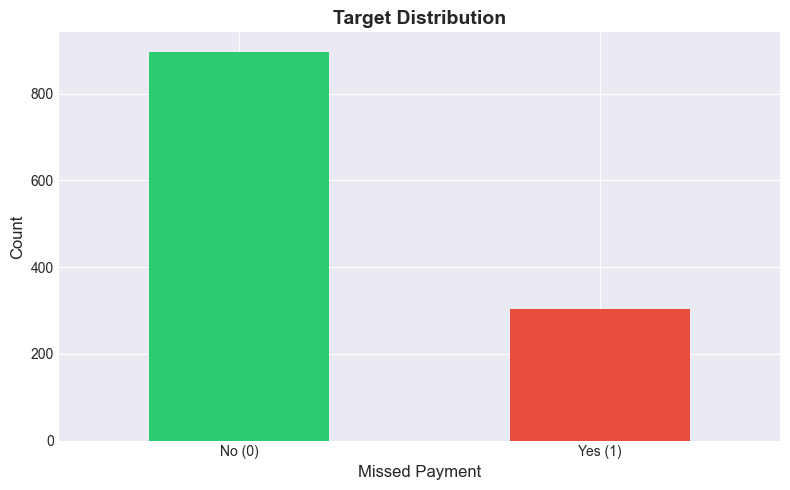


Saved: results/target_distribution.png


In [3]:
# Encode target: Yes=1 (missed payment), No=0 (no missed payment)
target_col = "missed_payment_last_12m"
y = (df[target_col].astype(str).str.strip().str.lower() == "yes").astype(int)

print("Target Distribution:")
print(f"  No (0):  {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"  Yes (1): {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")
print(f"  Ratio (1:0): 1:{(y==0).sum()/(y==1).sum():.2f}")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y.value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Target Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Missed Payment', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
plt.tight_layout()
plt.savefig('../results/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: results/target_distribution.png")

## 4. Feature Engineering

In [4]:
# Remove forbidden features (leakage, identifiers)
forbidden = ["business_id", "risk_class", "risk_score", "target_missed_payment", "split"]
X = df.drop(columns=[target_col] + [c for c in forbidden if c in df.columns])

# Combine text features
text_cols = ['business_description', 'loan_purpose_description', 
             'repayment_plan_description', 'risk_factors_description']

X2 = X.copy()
X2["text_all"] = X2[text_cols].fillna("").astype(str).agg(" ".join, axis=1)\
    .str.replace(r"\s+", " ", regex=True).str.strip()
X2 = X2.drop(columns=text_cols)

# Identify column types
cat_cols = [c for c in X2.columns if X2[c].dtype == "object" and c != "text_all"]
num_cols = [c for c in X2.columns if X2[c].dtype in ['int64', 'float64']]

print(f"Feature Summary:")
print(f"  Numeric features: {len(num_cols)}")
print(f"  Categorical features: {len(cat_cols)}")
print(f"  Text features: 1 (combined)")
print(f"\nNumeric features: {num_cols}")
print(f"\nCategorical features: {cat_cols}")

Feature Summary:
  Numeric features: 10
  Categorical features: 9
  Text features: 1 (combined)

Numeric features: ['business_age_years', 'employees_count', 'monthly_revenue_bdt', 'monthly_profit_bdt', 'prior_loan_count', 'loan_amount_bdt', 'preferred_tenure_months', 'cashflow_stability', 'repayment_confidence', 'days_payable_outstanding']

Categorical features: ['sector', 'legal_status', 'division', 'location_type', 'existing_loans', 'late_payment_history', 'loan_purpose', 'collateral_level', 'owner_education']


## 5. Build Preprocessing Pipelines

In [5]:
# Numeric transformer
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False))
])

# Categorical transformer
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

# Text transformer
text_transformer = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=200, ngram_range=(1, 2), min_df=3, max_df=0.95))
])

# Tabular-only preprocessor
preprocessor_tab = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], sparse_threshold=0.3)

# Combined preprocessor (tabular + text)
preprocessor_combined = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
    ('text', text_transformer, 'text_all')
], sparse_threshold=0.3)

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
scale_pos_weight = class_weights[1] / class_weights[0]

print(f"Class weights: {class_weight_dict}")
print(f"XGBoost scale_pos_weight: {scale_pos_weight:.3f}")
print("\nPreprocessing pipelines ready!")

Class weights: {0: np.float64(0.6688963210702341), 1: np.float64(1.9801980198019802)}
XGBoost scale_pos_weight: 2.960

Preprocessing pipelines ready!


## 6. Define Models

In [6]:
# Model definitions
models = {}

# Tabular-only baseline
models['LR (Tabular Only)'] = Pipeline([
    ('preprocessor', preprocessor_tab),
    ('classifier', LogisticRegression(max_iter=10000, C=1.0, 
                                      class_weight=class_weight_dict, 
                                      random_state=RANDOM_STATE))
])

# Combined models (tabular + text)
models['LR (Tab + Text)'] = Pipeline([
    ('preprocessor', preprocessor_combined),
    ('classifier', LogisticRegression(max_iter=10000, C=1.0, 
                                      class_weight=class_weight_dict, 
                                      random_state=RANDOM_STATE))
])

models['Random Forest'] = Pipeline([
    ('preprocessor', preprocessor_combined),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=10, 
                                          class_weight=class_weight_dict, 
                                          random_state=RANDOM_STATE, n_jobs=-1))
])

if HAS_XGB:
    models['XGBoost'] = Pipeline([
        ('preprocessor', preprocessor_combined),
        ('classifier', xgb.XGBClassifier(n_estimators=200, max_depth=6, 
                                         learning_rate=0.1, 
                                         scale_pos_weight=scale_pos_weight, 
                                         random_state=RANDOM_STATE, 
                                         eval_metric='logloss'))
    ])

print(f"Models defined: {list(models.keys())}")

Models defined: ['LR (Tabular Only)', 'LR (Tab + Text)', 'Random Forest', 'XGBoost']


## 7. Run 5-Fold Cross-Validation

In [7]:
# Prepare data
X_tab = X2.drop(columns=['text_all'])  # Tabular only
X_full = X2  # Tabular + text

# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
    'brier': make_scorer(brier_score_loss, greater_is_better=False)
}

# Run CV for each model
results = {}
print("Running 5-fold cross-validation...\n")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Select appropriate data
    X_data = X_tab if 'Tabular Only' in name else X_full
    
    # Cross-validate
    scores = cross_validate(model, X_data, y, cv=cv, scoring=scoring,
                           n_jobs=1, return_train_score=True, verbose=0)
    
    results[name] = scores
    
    # Display results
    test_roc = scores['test_roc_auc'].mean()
    test_roc_std = scores['test_roc_auc'].std()
    train_roc = scores['train_roc_auc'].mean()
    gap = train_roc - test_roc
    
    print(f"  Test ROC-AUC:  {test_roc:.4f} +/- {test_roc_std:.4f}")
    print(f"  Train ROC-AUC: {train_roc:.4f}")
    print(f"  Gap:           {gap:.4f}")
    print()

print("Cross-validation complete!")

Running 5-fold cross-validation...

Training LR (Tabular Only)...
  Test ROC-AUC:  0.8995 +/- 0.0240
  Train ROC-AUC: 0.9167
  Gap:           0.0172

Training LR (Tab + Text)...
  Test ROC-AUC:  0.8987 +/- 0.0232
  Train ROC-AUC: 0.9280
  Gap:           0.0293

Training Random Forest...
  Test ROC-AUC:  0.8103 +/- 0.0185
  Train ROC-AUC: 1.0000
  Gap:           0.1897

Training XGBoost...
  Test ROC-AUC:  0.8751 +/- 0.0186
  Train ROC-AUC: 1.0000
  Gap:           0.1249

Cross-validation complete!


## 8. Performance Comparison Table

In [8]:
# Create results table
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test ROC-AUC': [f"{results[m]['test_roc_auc'].mean():.4f} +/- {results[m]['test_roc_auc'].std():.4f}" for m in results.keys()],
    'Test PR-AUC': [f"{results[m]['test_average_precision'].mean():.4f} +/- {results[m]['test_average_precision'].std():.4f}" for m in results.keys()],
    'Test Brier': [f"{-results[m]['test_brier'].mean():.4f} +/- {-results[m]['test_brier'].std():.4f}" for m in results.keys()],
    'Train ROC-AUC': [f"{results[m]['train_roc_auc'].mean():.4f}" for m in results.keys()],
    'Gap': [f"{results[m]['train_roc_auc'].mean() - results[m]['test_roc_auc'].mean():.4f}" for m in results.keys()]
})

print("\n" + "="*100)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

# Save to CSV
results_df.to_csv('../results/cv_results_summary.csv', index=False)
print("\nSaved: results/cv_results_summary.csv")


CROSS-VALIDATION RESULTS SUMMARY
            Model      Test ROC-AUC       Test PR-AUC         Test Brier Train ROC-AUC    Gap
LR (Tabular Only) 0.8995 +/- 0.0240 0.7758 +/- 0.0445 0.1942 +/- -0.0321        0.9167 0.0172
  LR (Tab + Text) 0.8987 +/- 0.0232 0.7801 +/- 0.0443 0.1908 +/- -0.0255        0.9280 0.0293
    Random Forest 0.8103 +/- 0.0185 0.6110 +/- 0.0376 0.2075 +/- -0.0072        1.0000 0.1897
          XGBoost 0.8751 +/- 0.0186 0.7173 +/- 0.0352 0.1742 +/- -0.0150        1.0000 0.1249

Saved: results/cv_results_summary.csv


## 9. Visualization: Model Performance Comparison

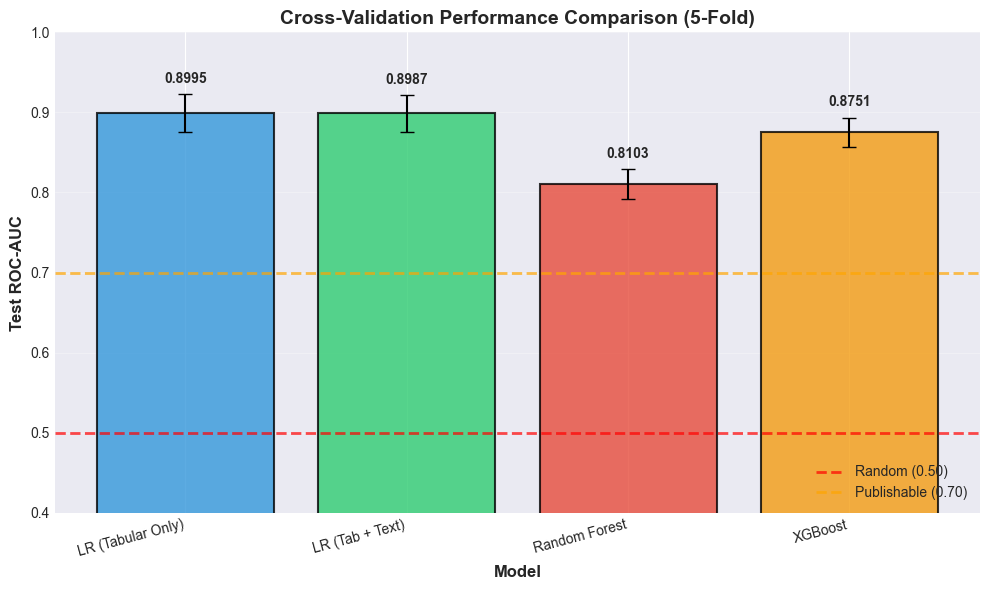

Saved: results/model_comparison.png


In [9]:
# Extract numeric values for plotting
model_names = list(results.keys())
roc_aucs = [results[m]['test_roc_auc'].mean() for m in model_names]
roc_stds = [results[m]['test_roc_auc'].std() for m in model_names]

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(model_names))
bars = ax.bar(x_pos, roc_aucs, yerr=roc_stds, capsize=5, 
              color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'][:len(model_names)],
              alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar, val, std) in enumerate(zip(bars, roc_aucs, roc_stds)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Formatting
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Test ROC-AUC', fontsize=12, fontweight='bold')
ax.set_title('Cross-Validation Performance Comparison (5-Fold)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Random (0.50)', alpha=0.7)
ax.axhline(y=0.7, color='orange', linestyle='--', linewidth=2, label='Publishable (0.70)', alpha=0.7)
ax.set_ylim([0.4, 1.0])
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: results/model_comparison.png")

## 10. Train Final Model on Full Dataset

In [10]:
# Select best model (highest test ROC-AUC)
best_model_name = max(results.items(), key=lambda x: x[1]['test_roc_auc'].mean())[0]
best_model = models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Test ROC-AUC: {results[best_model_name]['test_roc_auc'].mean():.4f}")
print("\nTraining on full dataset...")

# Select data
X_data = X_tab if 'Tabular Only' in best_model_name else X_full

# Train
best_model.fit(X_data, y)

# Predictions
y_pred = best_model.predict(X_data)
y_pred_proba = best_model.predict_proba(X_data)[:, 1]

# Metrics
train_roc_auc = roc_auc_score(y, y_pred_proba)
train_pr_auc = average_precision_score(y, y_pred_proba)

print(f"\nTraining set performance:")
print(f"  ROC-AUC: {train_roc_auc:.4f}")
print(f"  PR-AUC:  {train_pr_auc:.4f}")
print("\nModel trained successfully!")

Best model: LR (Tabular Only)
Test ROC-AUC: 0.8995

Training on full dataset...

Training set performance:
  ROC-AUC: 0.9150
  PR-AUC:  0.7966

Model trained successfully!


## 11. Confusion Matrix

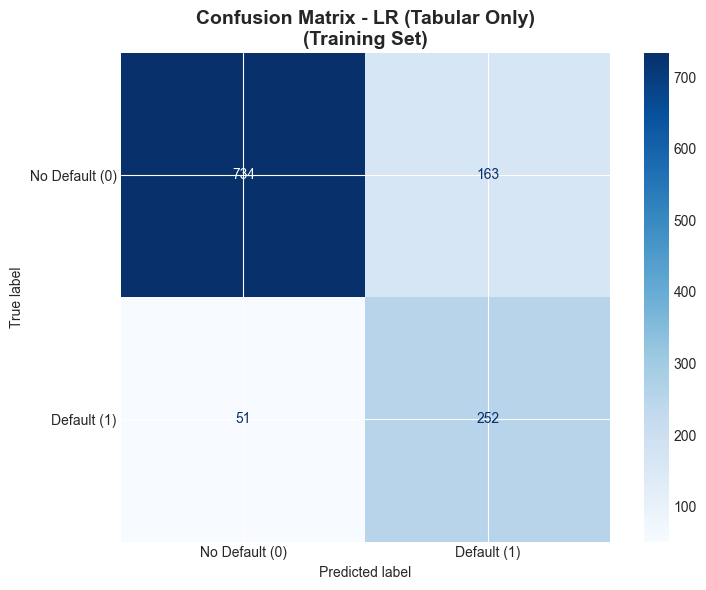


Confusion Matrix Statistics:
  True Negatives (TN):  734
  False Positives (FP): 163
  False Negatives (FN): 51
  True Positives (TP):  252

  Sensitivity (Recall): 0.8317 (83.2%)
  Specificity:          0.8183 (81.8%)
  Precision:            0.6072 (60.7%)
  F1-Score:             0.7019

Saved: results/confusion_matrix.png


In [11]:
# Compute confusion matrix
cm = confusion_matrix(y, y_pred)

# Display
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default (0)', 'Default (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'Confusion Matrix - {best_model_name}\n(Training Set)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
f1 = 2 * (precision * sensitivity) / (precision + sensitivity)

print("\nConfusion Matrix Statistics:")
print(f"  True Negatives (TN):  {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP):  {tp}")
print(f"\n  Sensitivity (Recall): {sensitivity:.4f} ({sensitivity*100:.1f}%)")
print(f"  Specificity:          {specificity:.4f} ({specificity*100:.1f}%)")
print(f"  Precision:            {precision:.4f} ({precision*100:.1f}%)")
print(f"  F1-Score:             {f1:.4f}")

print("\nSaved: results/confusion_matrix.png")

## 12. ROC Curves (All Models)

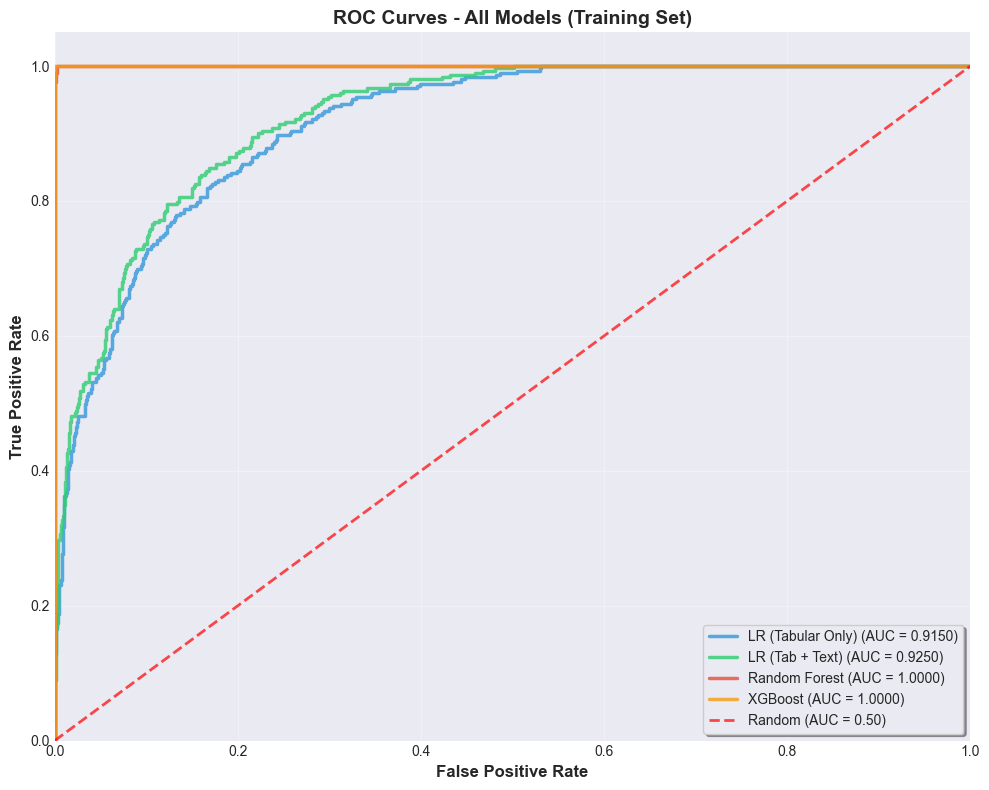

Saved: results/roc_curves_all_models.png


In [12]:
# Train all models and get predictions
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, (name, model) in enumerate(models.items()):
    # Select data
    X_data = X_tab if 'Tabular Only' in name else X_full
    
    # Train
    model.fit(X_data, y)
    
    # Predict
    y_proba = model.predict_proba(X_data)[:, 1]
    
    # Compute ROC
    fpr, tpr, _ = roc_curve(y, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    ax.plot(fpr, tpr, color=colors[i % len(colors)], lw=2.5, 
            label=f'{name} (AUC = {roc_auc:.4f})', alpha=0.8)

# Random classifier
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random (AUC = 0.50)', alpha=0.7)

# Formatting
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves - All Models (Training Set)', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10, frameon=True, shadow=True)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/roc_curves_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: results/roc_curves_all_models.png")

## 13. Precision-Recall Curves

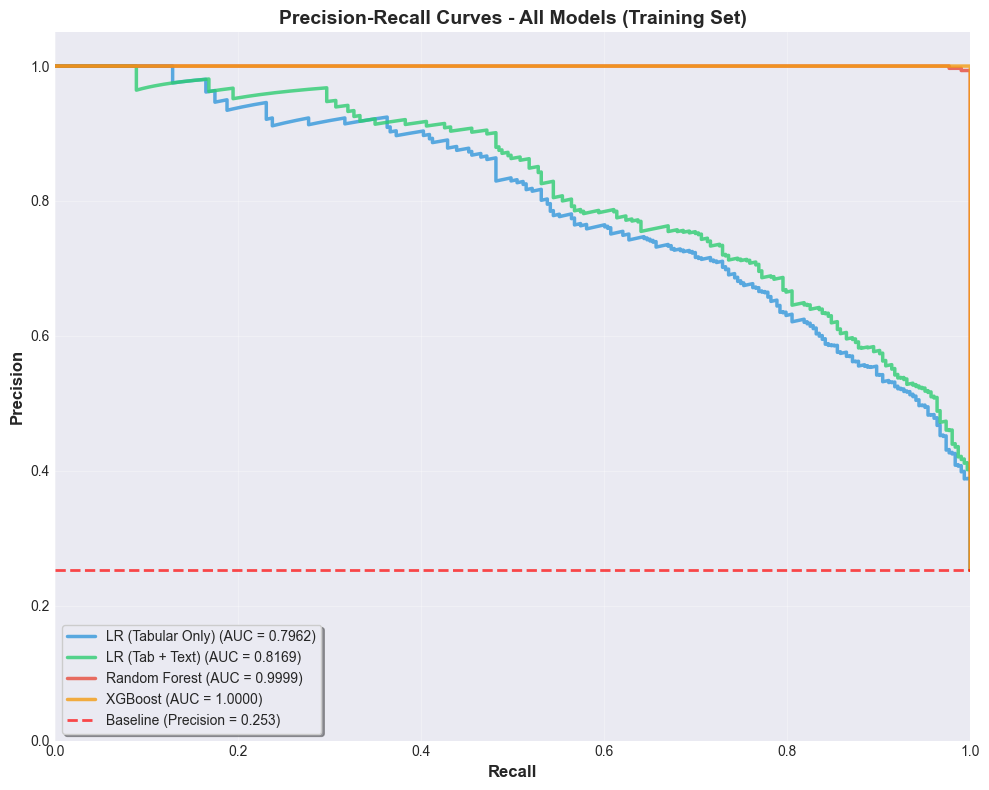

Saved: results/pr_curves_all_models.png


In [13]:
# PR Curves for all models
fig, ax = plt.subplots(figsize=(10, 8))

baseline_precision = (y == 1).sum() / len(y)

for i, (name, model) in enumerate(models.items()):
    # Select data
    X_data = X_tab if 'Tabular Only' in name else X_full
    
    # Train (already trained, but for consistency)
    model.fit(X_data, y)
    
    # Predict
    y_proba = model.predict_proba(X_data)[:, 1]
    
    # Compute PR curve
    precision, recall, _ = precision_recall_curve(y, y_proba)
    pr_auc = auc(recall, precision)
    
    # Plot
    ax.plot(recall, precision, color=colors[i % len(colors)], lw=2.5,
            label=f'{name} (AUC = {pr_auc:.4f})', alpha=0.8)

# Baseline
ax.axhline(y=baseline_precision, color='red', linestyle='--', lw=2,
           label=f'Baseline (Precision = {baseline_precision:.3f})', alpha=0.7)

# Formatting
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Precision-Recall Curves - All Models (Training Set)', fontsize=14, fontweight='bold')
ax.legend(loc="lower left", fontsize=10, frameon=True, shadow=True)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/pr_curves_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: results/pr_curves_all_models.png")

## 14. Calibration Curve

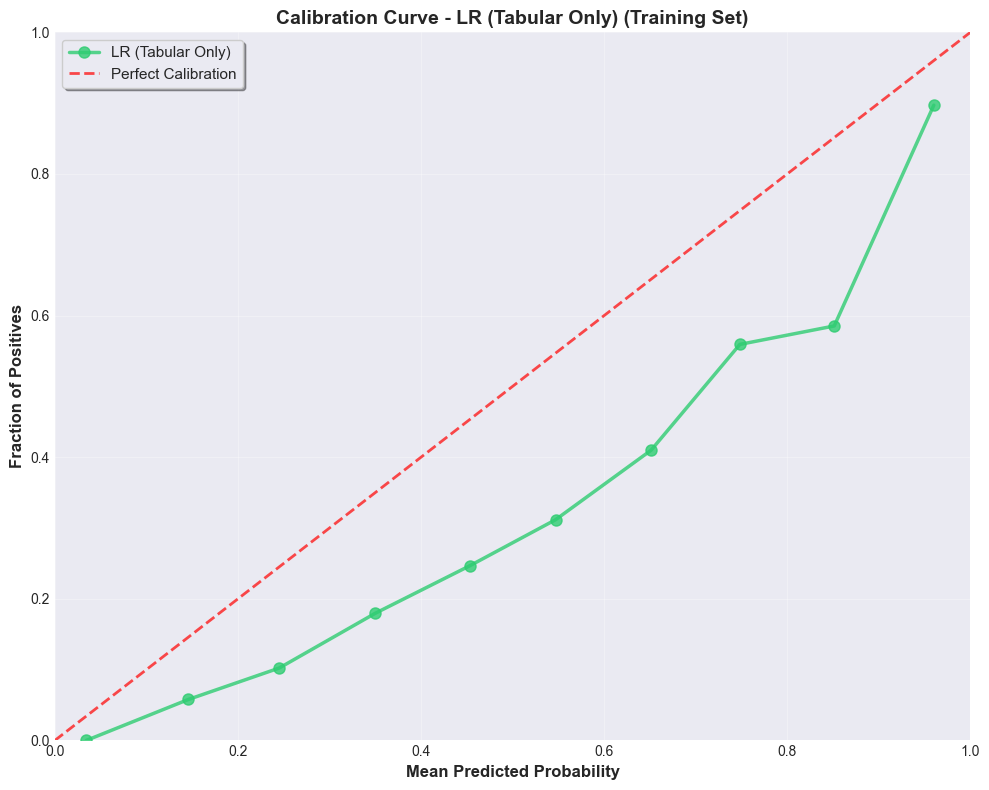

Saved: results/calibration_curve.png


In [14]:
# Calibration curve for best model
fig, ax = plt.subplots(figsize=(10, 8))

# Get predictions from best model
X_data = X_tab if 'Tabular Only' in best_model_name else X_full
best_model.fit(X_data, y)
y_proba = best_model.predict_proba(X_data)[:, 1]

# Compute calibration
prob_true, prob_pred = calibration_curve(y, y_proba, n_bins=10, strategy='uniform')

# Plot
ax.plot(prob_pred, prob_true, marker='o', linewidth=2.5, markersize=8,
        color='#2ecc71', label=f'{best_model_name}', alpha=0.8)
ax.plot([0, 1], [0, 1], linestyle='--', color='red', linewidth=2, 
        label='Perfect Calibration', alpha=0.7)

# Formatting
ax.set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
ax.set_ylabel('Fraction of Positives', fontsize=12, fontweight='bold')
ax.set_title(f'Calibration Curve - {best_model_name} (Training Set)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('../results/calibration_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: results/calibration_curve.png")

## 15. Feature Importance (Logistic Regression Coefficients)

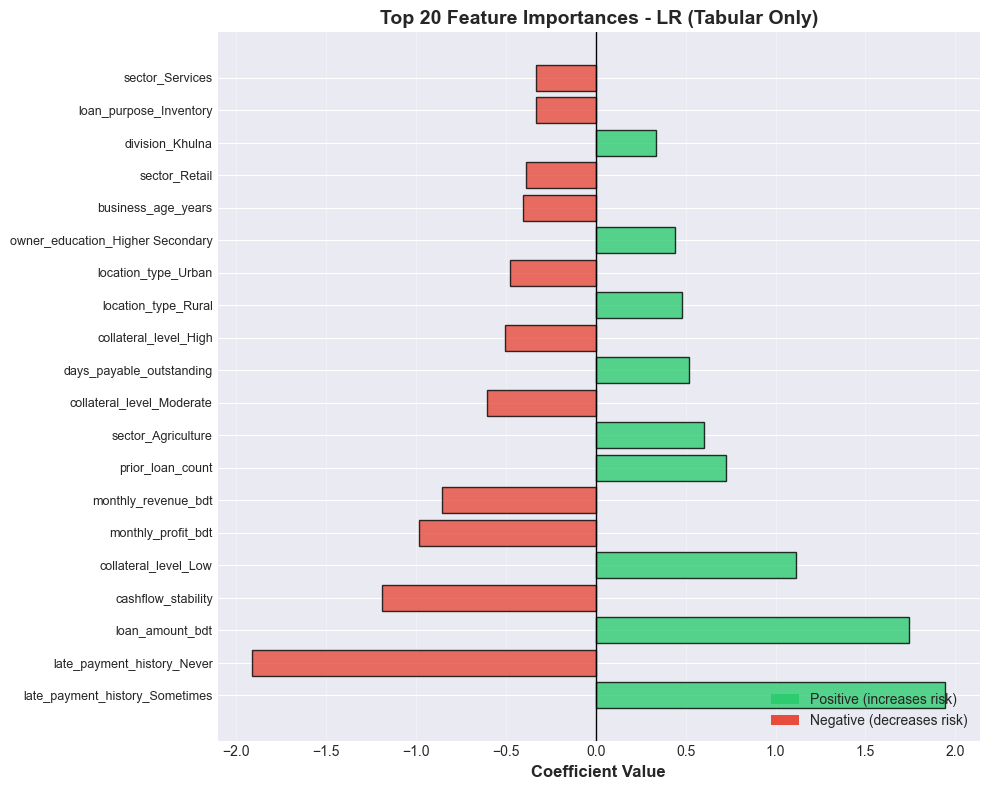

Saved: results/feature_importance_lr.png
Saved: results/feature_importance_lr.csv

Top 10 Most Important Features:
                       Feature  Coefficient
late_payment_history_Sometimes     1.944060
    late_payment_history_Never    -1.909147
               loan_amount_bdt     1.740852
            cashflow_stability    -1.190315
          collateral_level_Low     1.111725
            monthly_profit_bdt    -0.984442
           monthly_revenue_bdt    -0.853130
              prior_loan_count     0.722414
            sector_Agriculture     0.604463
     collateral_level_Moderate    -0.604189


In [15]:
# Extract feature importance for Logistic Regression
if 'LR' in best_model_name:
    # Get feature names after preprocessing
    preprocessor = best_model.named_steps['preprocessor']
    classifier = best_model.named_steps['classifier']
    
    # Fit preprocessor to get feature names
    X_data_fit = X_tab if 'Tabular Only' in best_model_name else X_full
    preprocessor.fit(X_data_fit, y)
    
    # Get feature names
    feature_names = []
    
    # Numeric features
    feature_names.extend(num_cols)
    
    # Categorical features (one-hot encoded)
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_features = cat_encoder.get_feature_names_out(cat_cols)
    feature_names.extend(cat_features)
    
    # Text features (if applicable)
    if 'text' in preprocessor.named_transformers_:
        text_vectorizer = preprocessor.named_transformers_['text'].named_steps['tfidf']
        text_features = [f"text_{word}" for word in text_vectorizer.get_feature_names_out()]
        feature_names.extend(text_features)
    
    # Get coefficients
    coef = classifier.coef_[0]
    
    # Create dataframe
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef,
        'Abs_Coefficient': np.abs(coef)
    }).sort_values('Abs_Coefficient', ascending=False)
    
    # Top 20 features
    top_features = feature_importance_df.head(20)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in top_features['Coefficient']]
    ax.barh(range(len(top_features)), top_features['Coefficient'], color=colors_bar, alpha=0.8, edgecolor='black')
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['Feature'], fontsize=9)
    ax.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
    ax.set_title(f'Top 20 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.grid(axis='x', alpha=0.3)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2ecc71', label='Positive (increases risk)'),
                      Patch(facecolor='#e74c3c', label='Negative (decreases risk)')]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('../results/feature_importance_lr.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save to CSV
    feature_importance_df.to_csv('../results/feature_importance_lr.csv', index=False)
    
    print("Saved: results/feature_importance_lr.png")
    print("Saved: results/feature_importance_lr.csv")
    print(f"\nTop 10 Most Important Features:")
    print(top_features.head(10)[['Feature', 'Coefficient']].to_string(index=False))
else:
    print(f"Feature importance extraction not implemented for {best_model_name}")

## 16. SHAP Analysis (if available)

Generating SHAP analysis...
This may take a few minutes...



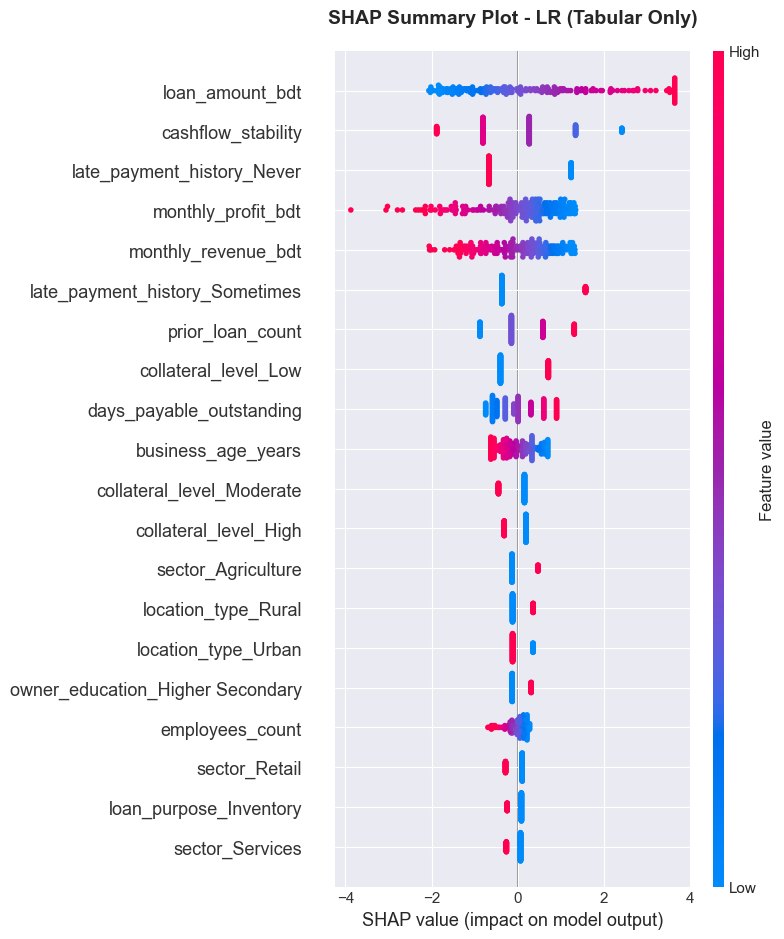

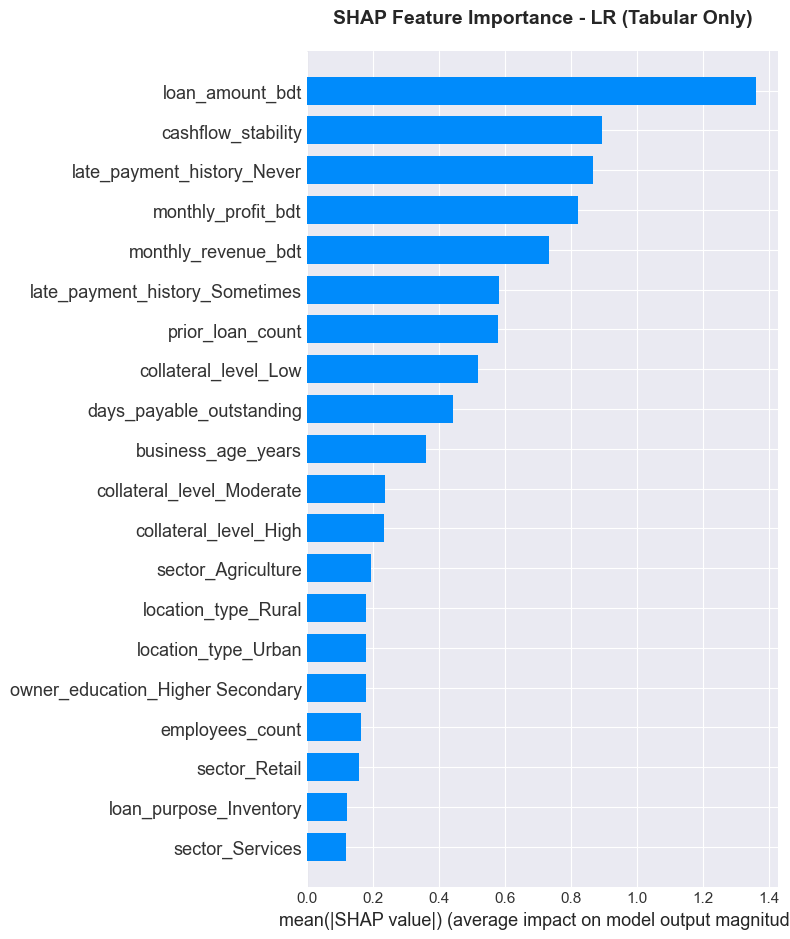

Saved: results/shap_summary.png
Saved: results/shap_bar.png


In [16]:
if HAS_SHAP:
    print("Generating SHAP analysis...")
    print("This may take a few minutes...\n")
    
    # Get transformed data
    X_data = X_tab if 'Tabular Only' in best_model_name else X_full
    X_transformed = best_model.named_steps['preprocessor'].transform(X_data)
    
    # Convert to dense if sparse
    if hasattr(X_transformed, 'toarray'):
        X_transformed = X_transformed.toarray()
    
    # Sample for SHAP (use subset for speed)
    sample_size = min(200, len(X_transformed))
    sample_idx = np.random.choice(len(X_transformed), sample_size, replace=False)
    X_sample = X_transformed[sample_idx]
    
    # Create explainer
    classifier = best_model.named_steps['classifier']
    
    if 'LR' in best_model_name:
        explainer = shap.LinearExplainer(classifier, X_sample)
        shap_values = explainer.shap_values(X_sample)
    else:
        explainer = shap.Explainer(classifier.predict, X_sample)
        shap_values = explainer(X_sample)
        if hasattr(shap_values, 'values'):
            shap_values = shap_values.values
    
    # SHAP summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, 
                     max_display=20, show=False)
    plt.title(f'SHAP Summary Plot - {best_model_name}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('../results/shap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # SHAP bar plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                     plot_type='bar', max_display=20, show=False)
    plt.title(f'SHAP Feature Importance - {best_model_name}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('../results/shap_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Saved: results/shap_summary.png")
    print("Saved: results/shap_bar.png")
else:
    print("SHAP not available. Install with: pip install shap")

## 17. Final Summary

In [17]:
print("\n" + "="*100)
print("FINAL SUMMARY - BANGLADESH SME CREDIT RISK ASSESSMENT")
print("="*100)

print(f"\nDataset: 1200 SME loan applications")
print(f"  - No default: {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"  - Default: {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")

print(f"\nBest Model: {best_model_name}")
print(f"  - Test ROC-AUC (CV):  {results[best_model_name]['test_roc_auc'].mean():.4f} +/- {results[best_model_name]['test_roc_auc'].std():.4f}")
print(f"  - Test PR-AUC (CV):   {results[best_model_name]['test_average_precision'].mean():.4f} +/- {results[best_model_name]['test_average_precision'].std():.4f}")
print(f"  - Train ROC-AUC:      {train_roc_auc:.4f}")
print(f"  - Train PR-AUC:       {train_pr_auc:.4f}")

print(f"\nClassification Performance (Training Set):")
print(f"  - Sensitivity (Recall): {sensitivity:.4f} ({sensitivity*100:.1f}%)")
print(f"  - Specificity:          {specificity:.4f} ({specificity*100:.1f}%)")
print(f"  - Precision:            {precision:.4f} ({precision*100:.1f}%)")
print(f"  - F1-Score:             {f1:.4f}")

# Comparison with baseline
baseline_roc = results['LR (Tabular Only)']['test_roc_auc'].mean()
best_roc = results[best_model_name]['test_roc_auc'].mean()
text_uplift = best_roc - baseline_roc

print(f"\nText Feature Analysis:")
print(f"  - Tabular-only baseline: {baseline_roc:.4f}")
print(f"  - Best model:            {best_roc:.4f}")
print(f"  - Text uplift:           {text_uplift:+.4f} ({text_uplift/baseline_roc*100:+.2f}%)")

# Publishability verdict
print(f"\n" + "="*100)
if best_roc > 0.70:
    print("VERDICT: PUBLISHABLE!")
    print(f"  Performance ({best_roc:.4f}) exceeds 0.70 threshold for Financial Innovation journal.")
    print(f"  Strong results suitable for publication.")
elif best_roc > 0.60:
    print("VERDICT: ACCEPTABLE")
    print(f"  Performance ({best_roc:.4f}) in 0.60-0.70 range.")
    print(f"  Methodology contribution possible with caveats.")
else:
    print("VERDICT: MARGINAL")
    print(f"  Performance ({best_roc:.4f}) < 0.60.")
    print(f"  May need additional feature engineering.")

print("="*100)

print("\n" + "="*100)
print("ANALYSIS COMPLETE!")
print("All results saved to: results/")
print("="*100)


FINAL SUMMARY - BANGLADESH SME CREDIT RISK ASSESSMENT

Dataset: 1200 SME loan applications
  - No default: 897 (74.8%)
  - Default: 303 (25.2%)

Best Model: LR (Tabular Only)
  - Test ROC-AUC (CV):  0.8995 +/- 0.0240
  - Test PR-AUC (CV):   0.7758 +/- 0.0445
  - Train ROC-AUC:      0.9150
  - Train PR-AUC:       0.7966

Classification Performance (Training Set):
  - Sensitivity (Recall): 0.8317 (83.2%)
  - Specificity:          0.8183 (81.8%)


TypeError: unsupported format string passed to numpy.ndarray.__format__